<a href="https://colab.research.google.com/github/Prajit-B/Interpretable-RL-Based-Sleep-Stagging/blob/main/EBMResults.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving reduced_dataset.csv to reduced_dataset.csv

✅ Loaded dataset: reduced_dataset.csv
Shape: (6000, 36)
         F9       F42       F21       F26       F16       F12       F24  \
0  0.001450  0.246886  0.349081  0.241975  0.022803  0.002483  0.002503   
1  0.018411  0.150352  0.415117  0.148971  0.027328  0.002500  0.002520   
2  0.002491  0.363919  0.138198  0.358848  0.031706  0.000914  0.000921   
3  0.035609  0.105593  0.413284  0.109465  0.023847  0.001085  0.001093   
4  0.010597  0.522701  0.444077  0.498765  0.084273  0.003159  0.003185   

        F17       F41        F7  ...        F5        F1       F32       F40  \
0  0.010650  0.033941  0.650514  ...  0.084044  0.589533  0.027243  0.156508   
1  0.019212  0.053624  0.847431  ...  0.105907  0.589918  0.048459  0.093061   
2  0.041206  0.130677  0.884066  ...  0.092083  0.598189  0.024242  0.074255   
3  0.016254  0.080090  0.792411  ...  0.121315  0.586869  0.031713  0.051852   
4  0.014569  0.058142  0.728375  ...  0.10

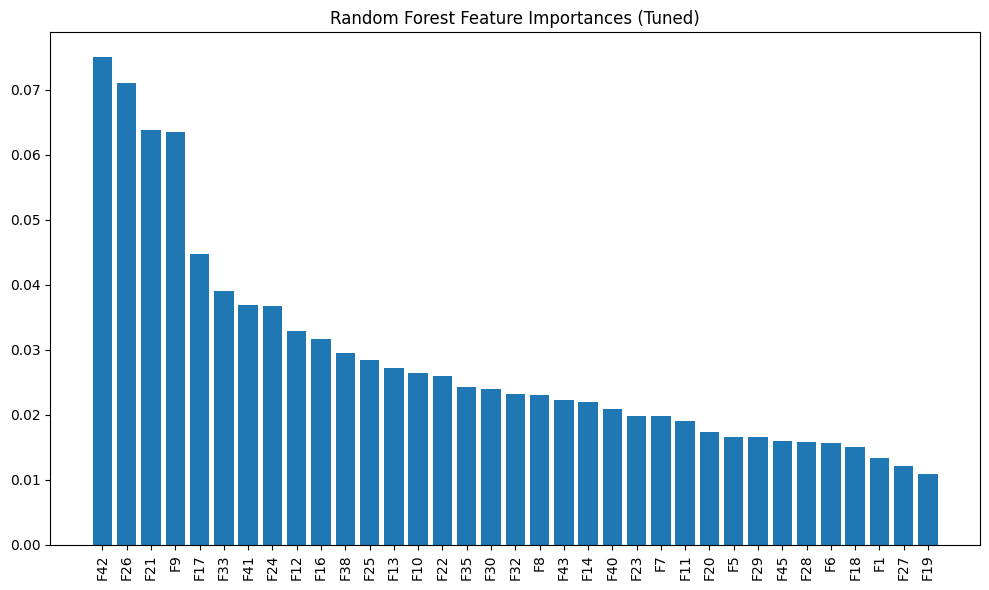

In [ ]:
# === INSTALL REQUIRED PACKAGES ===
!pip install -q scikit-learn pandas matplotlib

# === UPLOAD CSV FILE ===
from google.colab import files
uploaded = files.upload()

# === IMPORTS ===
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# === LOAD DATA ===
filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"\n✅ Loaded dataset: {filename}")
print(f"Shape: {df.shape}")
print(df.head())

# === SPLIT FEATURES AND LABEL ===
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# === TRAIN/TEST SPLIT ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"\n📊 Train: {len(X_train)}, Test: {len(X_test)}")

# === RANDOM FOREST HYPERPARAMETER GRID ===
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# === RANDOMIZED SEARCH ===
base_model = RandomForestClassifier(random_state=42)
search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    scoring='accuracy'
)
search.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {search.best_params_}")

# === BEST MODEL PREDICTION ===
best_rf = search.best_estimator_
y_pred = best_rf.predict(X_test)

# === EVALUATION ===
print("\n🏆 Tuned Random Forest Evaluation:")
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# === FEATURE IMPORTANCE PLOT ===
importances = best_rf.feature_importances_
feat_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importances (Tuned)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feat_names[indices], rotation=90)
plt.tight_layout()
plt.show()


Saving reduced_dataset.csv to reduced_dataset (1).csv

✅ Loaded dataset: reduced_dataset (1).csv
Shape: (6000, 36)
         F9       F42       F21       F26       F16       F12       F24  \
0  0.001450  0.246886  0.349081  0.241975  0.022803  0.002483  0.002503   
1  0.018411  0.150352  0.415117  0.148971  0.027328  0.002500  0.002520   
2  0.002491  0.363919  0.138198  0.358848  0.031706  0.000914  0.000921   
3  0.035609  0.105593  0.413284  0.109465  0.023847  0.001085  0.001093   
4  0.010597  0.522701  0.444077  0.498765  0.084273  0.003159  0.003185   

        F17       F41        F7  ...        F5        F1       F32       F40  \
0  0.010650  0.033941  0.650514  ...  0.084044  0.589533  0.027243  0.156508   
1  0.019212  0.053624  0.847431  ...  0.105907  0.589918  0.048459  0.093061   
2  0.041206  0.130677  0.884066  ...  0.092083  0.598189  0.024242  0.074255   
3  0.016254  0.080090  0.792411  ...  0.121315  0.586869  0.031713  0.051852   
4  0.014569  0.058142  0.728375  .

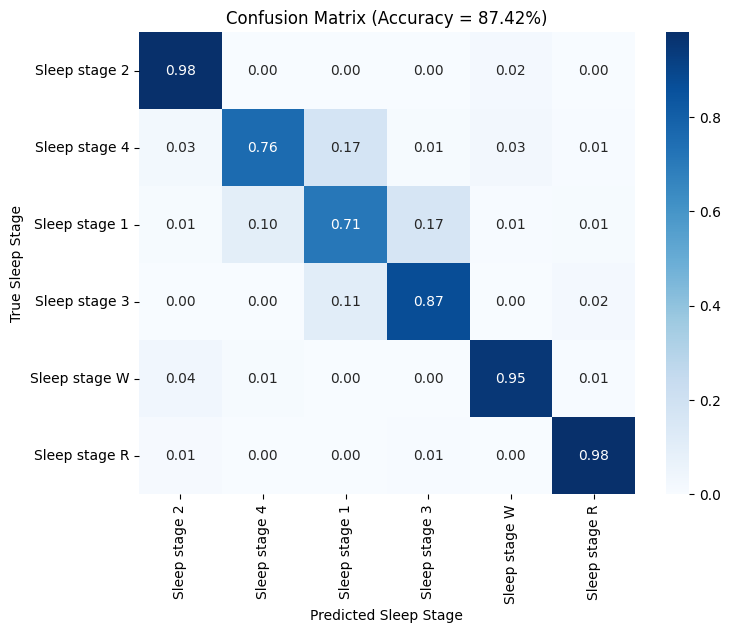

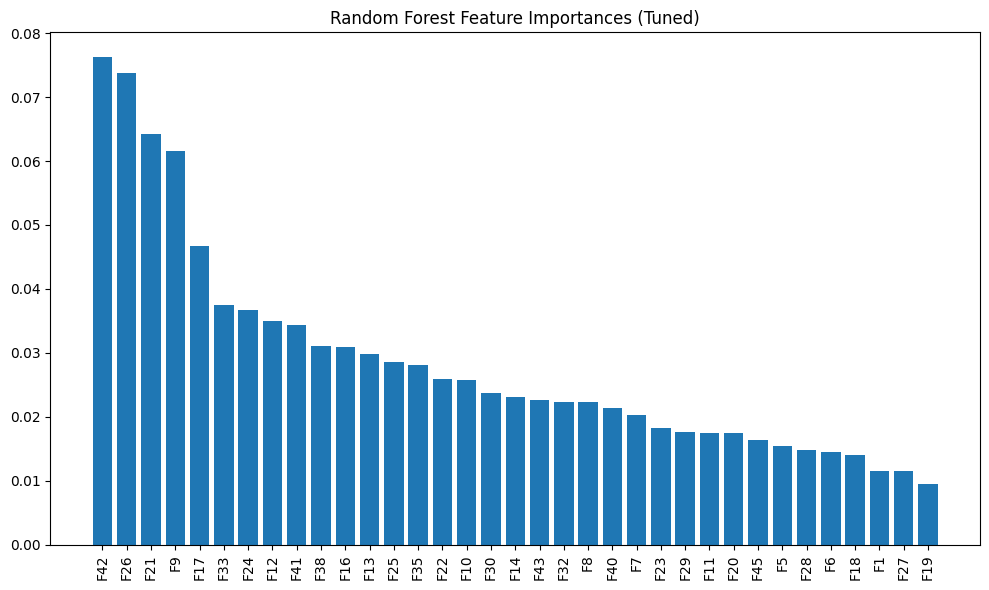

In [ ]:
# === INSTALL PACKAGES ===
!pip install -q scikit-learn pandas matplotlib seaborn

# === UPLOAD CSV FILE ===
from google.colab import files
uploaded = files.upload()

# === IMPORTS ===
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# === LOAD DATA ===
filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"\n✅ Loaded dataset: {filename}")
print(f"Shape: {df.shape}")
print(df.head())

# === SPLIT FEATURES AND LABEL ===
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Save original class names for confusion matrix
class_names = y.unique().tolist()

# Encode labels for training
y = LabelEncoder().fit_transform(y)

# === TRAIN/TEST SPLIT ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"\n📊 Train: {len(X_train)}, Test: {len(X_test)}")

# === MANUAL RANDOM FOREST HYPERPARAMETERS ===
best_rf = RandomForestClassifier(
    n_estimators=800,          # number of trees
    max_depth=30,              # limit depth to avoid overfitting
    min_samples_split=5,       # min samples to split a node
    min_samples_leaf=2,        # min samples in a leaf node
    max_features='sqrt',       # use sqrt(features) per split
    bootstrap=True,            # bootstrap sampling
    class_weight='balanced',   # handles sleep stage imbalance
    random_state=42,
    n_jobs=-1
)

# === TRAIN MODEL ===
best_rf.fit(X_train, y_train)

# === PREDICT ===
y_pred = best_rf.predict(X_test)

# === EVALUATION ===
test_acc = accuracy_score(y_test, y_pred)
print("\n🏆 Manual Random Forest Evaluation:")
print("Test Accuracy:", test_acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=class_names, digits=4))

# === CONFUSION MATRIX HEATMAP ===
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Sleep Stage")
plt.ylabel("True Sleep Stage")
plt.title(f"Confusion Matrix (Accuracy = {test_acc:.2%})")
plt.show()

# === FEATURE IMPORTANCE PLOT ===
importances = best_rf.feature_importances_
feat_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importances (Tuned)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feat_names[indices], rotation=90)
plt.tight_layout()
plt.show()


Saving reduced_dataset.csv to reduced_dataset (2).csv

✅ Loaded dataset: reduced_dataset (2).csv
Shape: (6000, 36)
         F9       F42       F21       F26       F16       F12       F24  \
0  0.001450  0.246886  0.349081  0.241975  0.022803  0.002483  0.002503   
1  0.018411  0.150352  0.415117  0.148971  0.027328  0.002500  0.002520   
2  0.002491  0.363919  0.138198  0.358848  0.031706  0.000914  0.000921   
3  0.035609  0.105593  0.413284  0.109465  0.023847  0.001085  0.001093   
4  0.010597  0.522701  0.444077  0.498765  0.084273  0.003159  0.003185   

        F17       F41        F7  ...        F5        F1       F32       F40  \
0  0.010650  0.033941  0.650514  ...  0.084044  0.589533  0.027243  0.156508   
1  0.019212  0.053624  0.847431  ...  0.105907  0.589918  0.048459  0.093061   
2  0.041206  0.130677  0.884066  ...  0.092083  0.598189  0.024242  0.074255   
3  0.016254  0.080090  0.792411  ...  0.121315  0.586869  0.031713  0.051852   
4  0.014569  0.058142  0.728375  .

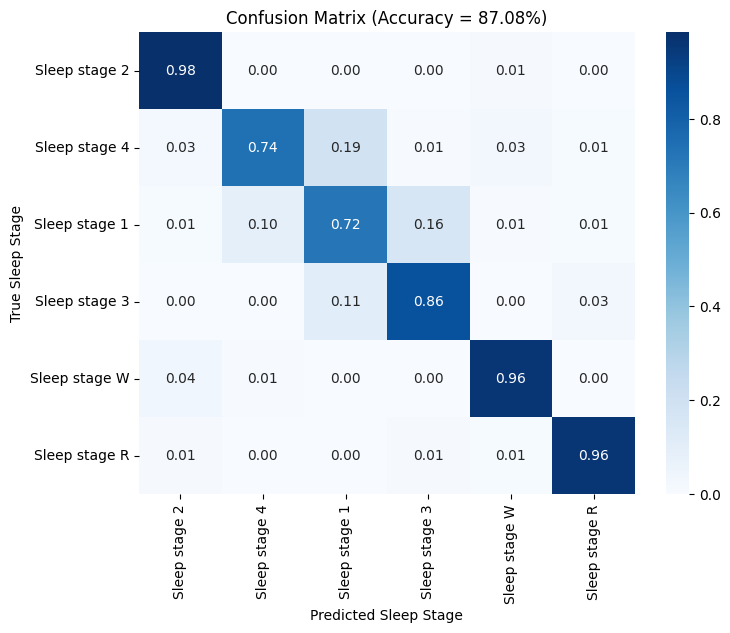

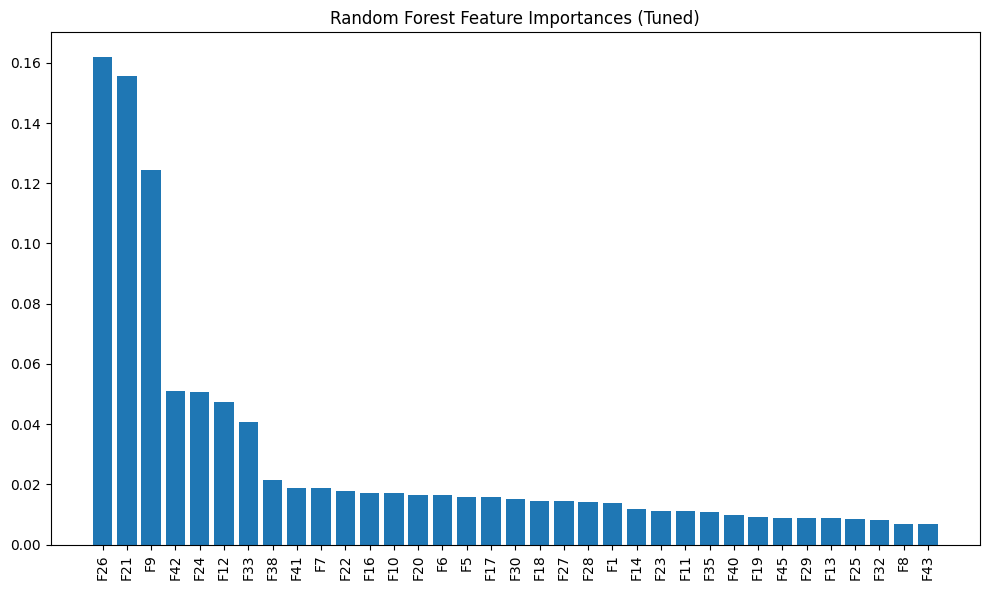

In [ ]:
# === INSTALL PACKAGES ===
!pip install -q scikit-learn pandas matplotlib seaborn

# === UPLOAD CSV FILE ===
from google.colab import files
uploaded = files.upload()

# === IMPORTS ===
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# === LOAD DATA ===
filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"\n✅ Loaded dataset: {filename}")
print(f"Shape: {df.shape}")
print(df.head())

# === SPLIT FEATURES AND LABEL ===
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Save original class names for confusion matrix
class_names = y.unique().tolist()

# Encode labels for training
y = LabelEncoder().fit_transform(y)

# === TRAIN/TEST SPLIT ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"\n📊 Train: {len(X_train)}, Test: {len(X_test)}")

# === STRONGER RANDOM FOREST HYPERPARAMETERS ===
best_rf = RandomForestClassifier(
    n_estimators=1200,        # more trees for stability
    max_depth=None,           # fully grown trees
    min_samples_split=2,      # allow splits aggressively
    min_samples_leaf=1,       # finer leaf nodes
    max_features=None,        # use all features
    bootstrap=True,
    class_weight='balanced',  # handle imbalanced sleep stages
    random_state=42,
    n_jobs=-1
)

# === TRAIN MODEL ===
best_rf.fit(X_train, y_train)

# === PREDICT ===
y_pred = best_rf.predict(X_test)

# === EVALUATION ===
test_acc = accuracy_score(y_test, y_pred)
print("\n🏆 Tuned Manual Random Forest Evaluation:")
print("Test Accuracy:", test_acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=class_names, digits=4))

# === CONFUSION MATRIX HEATMAP ===
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Sleep Stage")
plt.ylabel("True Sleep Stage")
plt.title(f"Confusion Matrix (Accuracy = {test_acc:.2%})")
plt.show()

# === FEATURE IMPORTANCE PLOT ===
importances = best_rf.feature_importances_
feat_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importances (Tuned)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feat_names[indices], rotation=90)
plt.tight_layout()
plt.show()


Saving reduced_dataset.csv to reduced_dataset (4).csv

✅ Loaded dataset: reduced_dataset (4).csv
Shape: (6000, 36)
         F9       F42       F21       F26       F16       F12       F24  \
0  0.001450  0.246886  0.349081  0.241975  0.022803  0.002483  0.002503   
1  0.018411  0.150352  0.415117  0.148971  0.027328  0.002500  0.002520   
2  0.002491  0.363919  0.138198  0.358848  0.031706  0.000914  0.000921   
3  0.035609  0.105593  0.413284  0.109465  0.023847  0.001085  0.001093   
4  0.010597  0.522701  0.444077  0.498765  0.084273  0.003159  0.003185   

        F17       F41        F7  ...        F5        F1       F32       F40  \
0  0.010650  0.033941  0.650514  ...  0.084044  0.589533  0.027243  0.156508   
1  0.019212  0.053624  0.847431  ...  0.105907  0.589918  0.048459  0.093061   
2  0.041206  0.130677  0.884066  ...  0.092083  0.598189  0.024242  0.074255   
3  0.016254  0.080090  0.792411  ...  0.121315  0.586869  0.031713  0.051852   
4  0.014569  0.058142  0.728375  .

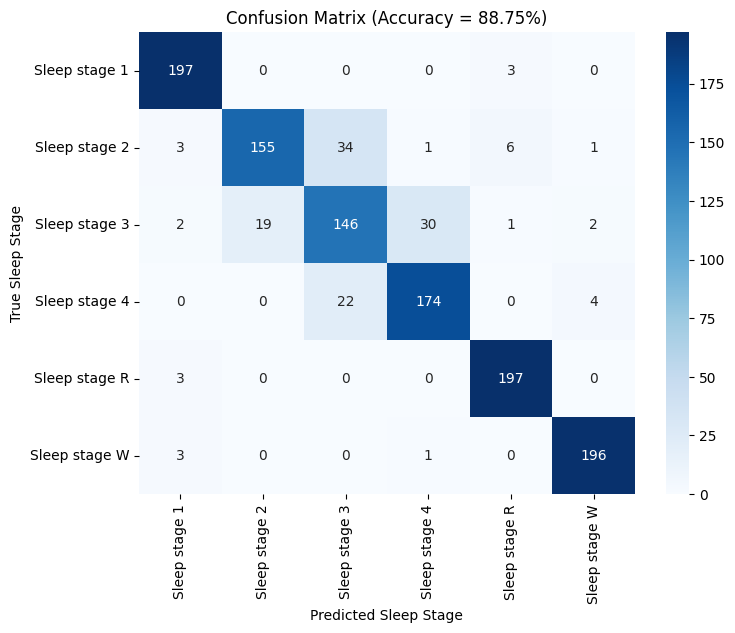

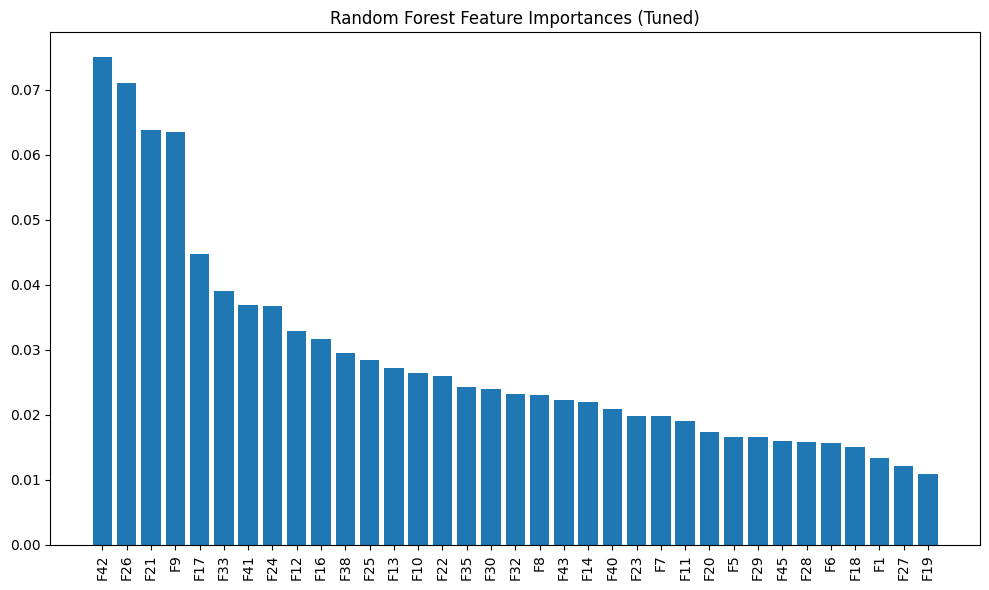

In [ ]:
# === INSTALL REQUIRED PACKAGES ===
!pip install -q scikit-learn pandas matplotlib seaborn

# === UPLOAD CSV FILE ===
from google.colab import files
uploaded = files.upload()

# === IMPORTS ===
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# === LOAD DATA ===
filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"\n✅ Loaded dataset: {filename}")
print(f"Shape: {df.shape}")
print(df.head())

# === SPLIT FEATURES AND LABEL ===
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Save original labels before encoding
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)
    class_names = le.classes_
else:
    class_names = np.unique(y).astype(str)

# === TRAIN/TEST SPLIT ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"\n📊 Train: {len(X_train)}, Test: {len(X_test)}")

# === RANDOM FOREST HYPERPARAMETER GRID ===
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# === RANDOMIZED SEARCH ===
base_model = RandomForestClassifier(random_state=42)
search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    scoring='accuracy'
)
search.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {search.best_params_}")

# === BEST MODEL PREDICTION ===
best_rf = search.best_estimator_
y_pred = best_rf.predict(X_test)

# === EVALUATION ===
acc = accuracy_score(y_test, y_pred)
print("\n🏆 Tuned Random Forest Evaluation:")
print("Test Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=class_names, digits=4))

# === CONFUSION MATRIX HEATMAP (RAW COUNTS) ===
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Sleep Stage")
plt.ylabel("True Sleep Stage")
plt.title(f"Confusion Matrix (Accuracy = {acc:.2%})")
plt.show()


# === FEATURE IMPORTANCE PLOT ===
importances = best_rf.feature_importances_
feat_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importances (Tuned)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feat_names[indices], rotation=90)
plt.tight_layout()
plt.show()


Saving reduced_dataset.csv to reduced_dataset (5).csv

✅ Loaded dataset: reduced_dataset (5).csv
Shape: (6000, 36)
         F9       F42       F21       F26       F16       F12       F24  \
0  0.001450  0.246886  0.349081  0.241975  0.022803  0.002483  0.002503   
1  0.018411  0.150352  0.415117  0.148971  0.027328  0.002500  0.002520   
2  0.002491  0.363919  0.138198  0.358848  0.031706  0.000914  0.000921   
3  0.035609  0.105593  0.413284  0.109465  0.023847  0.001085  0.001093   
4  0.010597  0.522701  0.444077  0.498765  0.084273  0.003159  0.003185   

        F17       F41        F7  ...        F5        F1       F32       F40  \
0  0.010650  0.033941  0.650514  ...  0.084044  0.589533  0.027243  0.156508   
1  0.019212  0.053624  0.847431  ...  0.105907  0.589918  0.048459  0.093061   
2  0.041206  0.130677  0.884066  ...  0.092083  0.598189  0.024242  0.074255   
3  0.016254  0.080090  0.792411  ...  0.121315  0.586869  0.031713  0.051852   
4  0.014569  0.058142  0.728375  .

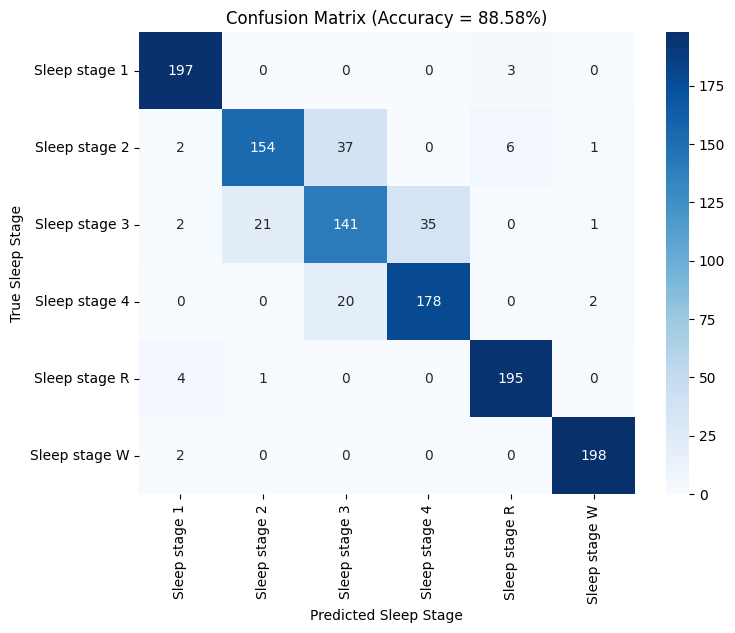

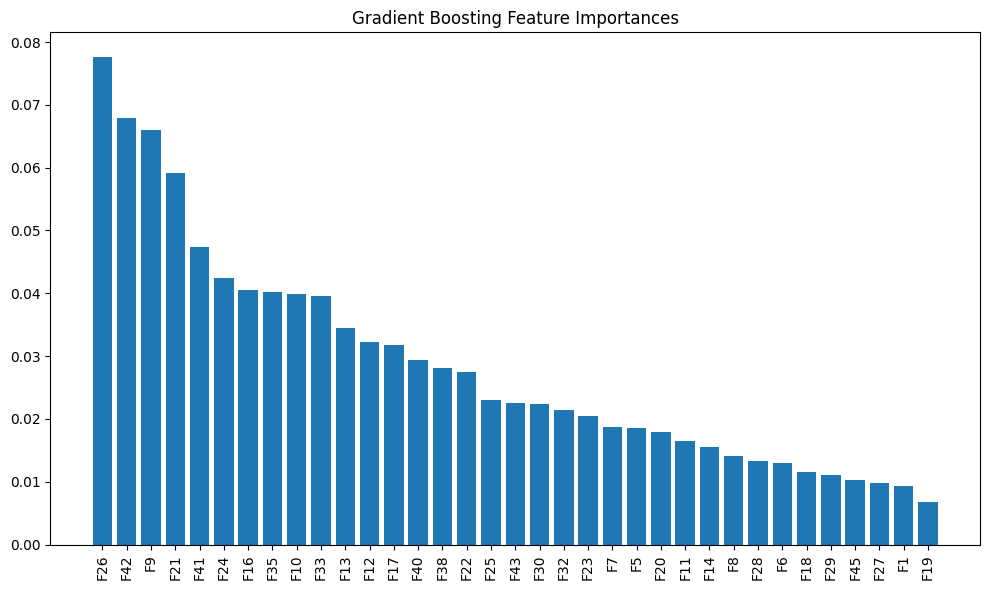

In [ ]:
# === INSTALL REQUIRED PACKAGES ===
!pip install -q scikit-learn pandas matplotlib seaborn

# === UPLOAD CSV FILE ===
from google.colab import files
uploaded = files.upload()

# === IMPORTS ===
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# === LOAD DATA ===
filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"\n✅ Loaded dataset: {filename}")
print(f"Shape: {df.shape}")
print(df.head())

# === SPLIT FEATURES / LABEL ===
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Save label names before encoding
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)
    class_names = le.classes_
else:
    class_names = np.unique(y).astype(str)

# === TRAIN/TEST SPLIT ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"\n📊 Train: {len(X_train)}, Test: {len(X_test)}")

# === GRADIENT BOOSTING HYPERPARAMETER GRID ===
param_dist = {
    'n_estimators': [150, 200, 300],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'subsample': [0.8, 1.0],
    'max_features': ['sqrt', 'log2']
}

# === RANDOMIZED SEARCH ===
base_model = GradientBoostingClassifier(random_state=42)
search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    scoring='accuracy'
)
search.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {search.best_params_}")

# === BEST MODEL PREDICTION ===
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

# === EVALUATION ===
acc = accuracy_score(y_test, y_pred)
print("\n🏆 Tuned Gradient Boosting Evaluation:")
print(f"Test Accuracy: {acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=class_names, digits=4))

# === CONFUSION MATRIX HEATMAP (RAW COUNTS) ===
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Sleep Stage")
plt.ylabel("True Sleep Stage")
plt.title(f"Confusion Matrix (Accuracy = {acc:.2%})")
plt.show()

# === FEATURE IMPORTANCE PLOT ===
importances = best_model.feature_importances_
feat_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Gradient Boosting Feature Importances")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feat_names[indices], rotation=90)
plt.tight_layout()
plt.show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.8 MB/s eta 0:00:00


Saving reduced_dataset.csv to reduced_dataset (6).csv

✅ Loaded dataset: reduced_dataset (6).csv
Shape: (6000, 36)
         F9       F42       F21       F26       F16       F12       F24  \
0  0.001450  0.246886  0.349081  0.241975  0.022803  0.002483  0.002503   
1  0.018411  0.150352  0.415117  0.148971  0.027328  0.002500  0.002520   
2  0.002491  0.363919  0.138198  0.358848  0.031706  0.000914  0.000921   
3  0.035609  0.105593  0.413284  0.109465  0.023847  0.001085  0.001093   
4  0.010597  0.522701  0.444077  0.498765  0.084273  0.003159  0.003185   

        F17       F41        F7  ...        F5        F1       F32       F40  \
0  0.010650  0.033941  0.650514  ...  0.084044  0.589533  0.027243  0.156508   
1  0.019212  0.053624  0.847431  ...  0.105907  0.589918  0.048459  0.093061   
2  0.041206  0.130677  0.884066  ...  0.092083  0.598189  0.024242  0.074255   
3  0.016254  0.080090  0.792411  ...  0.121315  0.586869  0.031713  0.051852   
4  0.014569  0.058142  0.728375  .

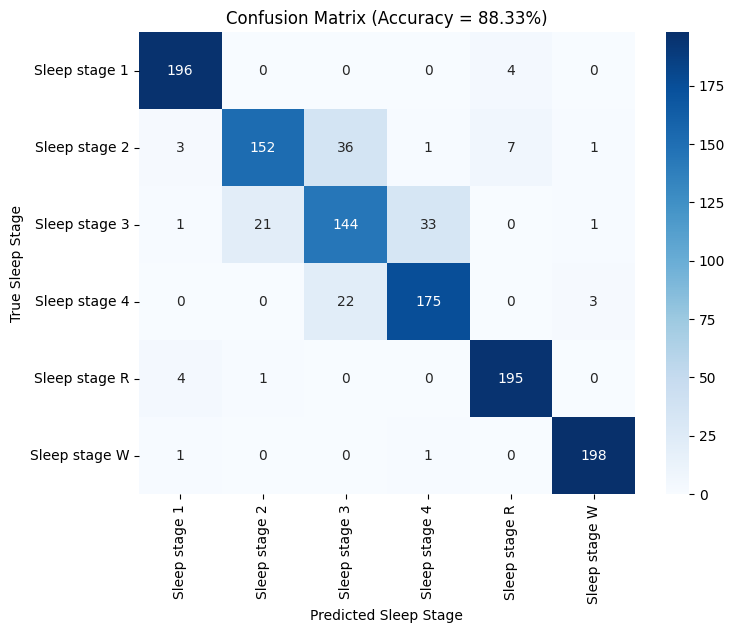


📊 Performance Matrix:
               precision  recall  f1-score    support
Sleep stage 1     0.9561  0.9800    0.9679   200.0000
Sleep stage 2     0.8736  0.7600    0.8128   200.0000
Sleep stage 3     0.7129  0.7200    0.7164   200.0000
Sleep stage 4     0.8333  0.8750    0.8537   200.0000
Sleep stage R     0.9466  0.9750    0.9606   200.0000
Sleep stage W     0.9754  0.9900    0.9826   200.0000
accuracy          0.8833  0.8833    0.8833     0.8833
macro avg         0.8830  0.8833    0.8823  1200.0000
weighted avg      0.8830  0.8833    0.8823  1200.0000


In [ ]:
# === INSTALL PACKAGES ===
!pip install -q scikit-learn xgboost catboost pandas matplotlib seaborn

# === UPLOAD CSV ===
from google.colab import files
uploaded = files.upload()

# === IMPORTS ===
import io
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder

# === LOAD DATA ===
filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"\n✅ Loaded dataset: {filename}")
print(f"Shape: {df.shape}")
print(df.head())

# === FEATURES & LABEL SPLIT ===
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Save label names
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)
    class_names = le.classes_
else:
    class_names = np.unique(y).astype(str)

# === TRAIN-TEST SPLIT ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"\n📊 Train: {len(X_train)}, Test: {len(X_test)}")

# === BASE MODELS ===
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
xgb = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5,
                    use_label_encoder=False, eval_metric='mlogloss', random_state=42)
cat = CatBoostClassifier(verbose=0, iterations=200, learning_rate=0.05, depth=5, random_state=42)

# === STACKING CLASSIFIER ===
stack_model = StackingClassifier(
    estimators=[
        ('gb', gb),
        ('xgb', xgb),
        ('cat', cat)
    ],
    final_estimator=LogisticRegression(max_iter=500),
    cv=5,
    n_jobs=-1,
    passthrough=True
)

# === TRAIN ===
stack_model.fit(X_train, y_train)
y_pred = stack_model.predict(X_test)

# === EVALUATION ===
acc = accuracy_score(y_test, y_pred)
print("\n🏆 Stacking Classifier Evaluation:")
print(f"Test Accuracy: {acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=class_names, digits=4))

# === CONFUSION MATRIX HEATMAP (RAW COUNTS) ===
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Sleep Stage")
plt.ylabel("True Sleep Stage")
plt.title(f"Confusion Matrix (Accuracy = {acc:.2%})")
plt.show()

# === PERFORMANCE MATRIX (DataFrame) ===
report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report).transpose()

print("\n📊 Performance Matrix:")
print(df_report.round(4))


Saving reduced_dataset.csv to reduced_dataset (8).csv


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:00:58] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Test Accuracy: 87.83 %

Classification Report:

               precision    recall  f1-score   support

Sleep stage 1       0.93      0.98      0.96       200
Sleep stage 2       0.87      0.75      0.81       200
Sleep stage 3       0.70      0.69      0.70       200
Sleep stage 4       0.83      0.88      0.85       200
Sleep stage R       0.96      0.97      0.96       200
Sleep stage W       0.98      0.99      0.99       200

     accuracy                           0.88      1200
    macro avg       0.88      0.88      0.88      1200
 weighted avg       0.88      0.88      0.88      1200



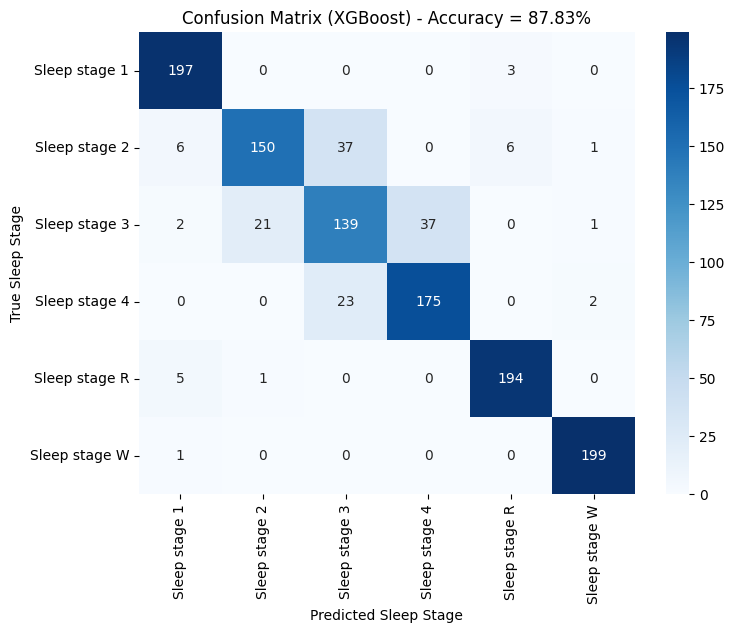

In [ ]:
# === INSTALL PACKAGES ===
!pip install -q scikit-learn pandas matplotlib xgboost

# === UPLOAD DATA ===
from google.colab import files
uploaded = files.upload()

# === IMPORTS ===
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# === READ DATA ===
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Separate features and label
X = df.drop(columns=['label'])
y = df['label']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# === TRAIN TEST SPLIT ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# === MODEL (XGBoost) ===
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# === EVALUATION ===
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", round(acc*100, 2), "%\n")

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix (Raw Counts with Sleep Stage Labels)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted Sleep Stage")
plt.ylabel("True Sleep Stage")
plt.title(f"Confusion Matrix (XGBoost) - Accuracy = {round(acc*100,2)}%")
plt.show()


Saving reduced_dataset.csv to reduced_dataset.csv
Voting Classifier Accuracy: 87.67%

Confusion Matrix (Raw Counts):
 [[197   0   0   0   3   0]
 [  6 148  36   2   7   1]
 [  2  18 140  37   1   2]
 [  0   0  23 175   0   2]
 [  6   1   0   0 193   0]
 [  1   0   0   0   0 199]]


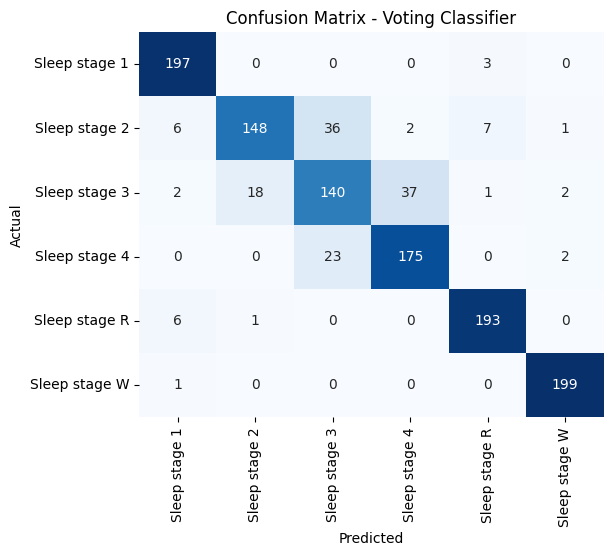


Classification Report:
                precision    recall  f1-score   support

Sleep stage 1       0.93      0.98      0.96       200
Sleep stage 2       0.89      0.74      0.81       200
Sleep stage 3       0.70      0.70      0.70       200
Sleep stage 4       0.82      0.88      0.85       200
Sleep stage R       0.95      0.96      0.96       200
Sleep stage W       0.98      0.99      0.99       200

     accuracy                           0.88      1200
    macro avg       0.88      0.88      0.88      1200
 weighted avg       0.88      0.88      0.88      1200


Results saved as voting_results.csv


In [ ]:
# === INSTALL PACKAGES ===
!pip install -q scikit-learn xgboost pandas matplotlib

# === IMPORTS ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# === LOAD DATA ===
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

# === FEATURES & LABELS ===
X = df.iloc[:, :-1]   # all feature columns
y = df.iloc[:, -1]    # last column as label

# === TRAIN/TEST SPLIT ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# === BASE MODELS ===
rf = RandomForestClassifier(n_estimators=200, random_state=42)
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42)
xgb = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42, use_label_encoder=False, eval_metric="mlogloss")

# === VOTING CLASSIFIER (SOFT VOTING) ===
voting_clf = VotingClassifier(
    estimators=[("rf", rf), ("gb", gb), ("xgb", xgb)],
    voting="soft",   # soft = uses probabilities, usually better than hard voting
    n_jobs=-1
)

# === TRAIN ===
voting_clf.fit(X_train, y_train)

# === PREDICT ===
y_pred = voting_clf.predict(X_test)

# === ACCURACY ===
acc = accuracy_score(y_test, y_pred)
print(f"Voting Classifier Accuracy: {acc*100:.2f}%")

# === CONFUSION MATRIX (RAW COUNTS, NO NORMALIZATION) ===
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix (Raw Counts):\n", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Voting Classifier")
plt.show()

# === CLASSIFICATION REPORT ===
report = classification_report(y_test, y_pred, output_dict=True)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# === SAVE RESULTS TO CSV ===
report_df = pd.DataFrame(report).transpose()
report_df.to_csv("voting_results.csv", index=True)

print("\nResults saved as voting_results.csv")


Saving reduced_dataset.csv to reduced_dataset (1).csv


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:53:48] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Test Accuracy: 87.83 %

Classification Report (4 decimal places):

               precision    recall  f1-score   support

Sleep stage 1     0.9336    0.9850    0.9586       200
Sleep stage 2     0.8721    0.7500    0.8065       200
Sleep stage 3     0.6985    0.6950    0.6967       200
Sleep stage 4     0.8255    0.8750    0.8495       200
Sleep stage R     0.9557    0.9700    0.9628       200
Sleep stage W     0.9803    0.9950    0.9876       200

     accuracy                         0.8783      1200
    macro avg     0.8776    0.8783    0.8770      1200
 weighted avg     0.8776    0.8783    0.8770      1200



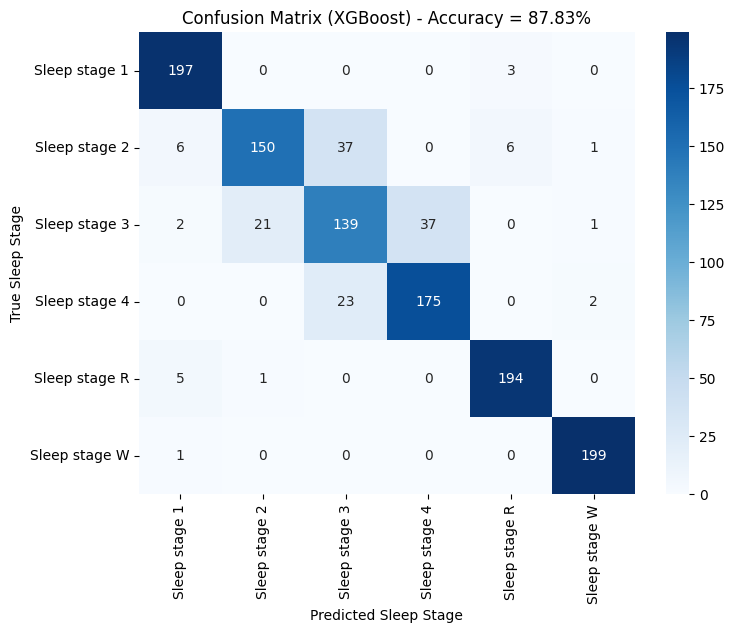

In [ ]:
# === INSTALL PACKAGES ===
!pip install -q scikit-learn pandas matplotlib xgboost

# === UPLOAD DATA ===
from google.colab import files
uploaded = files.upload()

# === IMPORTS ===
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# === READ DATA ===
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Separate features and label
X = df.drop(columns=['label'])
y = df['label']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# === TRAIN TEST SPLIT ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# === MODEL (XGBoost) ===
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# === EVALUATION ===
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", round(acc*100, 2), "%\n")

# Performance matrix (4 decimal places)
print("Classification Report (4 decimal places):\n")
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))

# Confusion Matrix (Raw Counts with Sleep Stage Labels)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted Sleep Stage")
plt.ylabel("True Sleep Stage")
plt.title(f"Confusion Matrix (XGBoost) - Accuracy = {round(acc*100,2)}%")
plt.show()


Saving reduced_dataset.csv to reduced_dataset (2).csv
Voting Classifier Accuracy: 87.67%

Confusion Matrix (Raw Counts):
 [[197   0   0   0   3   0]
 [  6 148  36   2   7   1]
 [  2  18 140  37   1   2]
 [  0   0  23 175   0   2]
 [  6   1   0   0 193   0]
 [  1   0   0   0   0 199]]


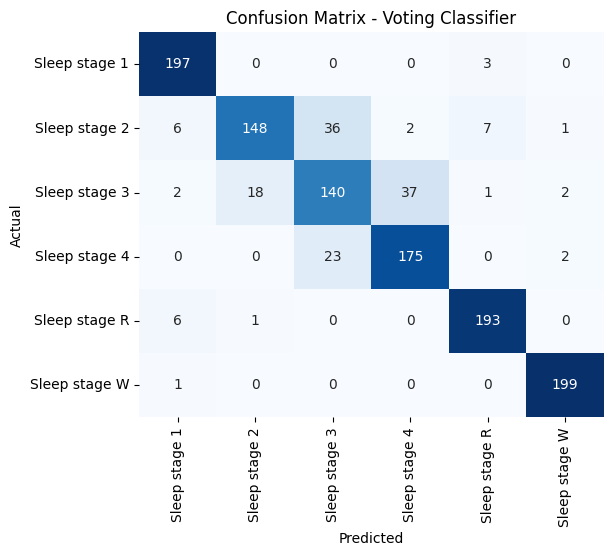


Classification Report (4 decimal places):

               precision    recall  f1-score   support

Sleep stage 1     0.9292    0.9850    0.9563       200
Sleep stage 2     0.8862    0.7400    0.8065       200
Sleep stage 3     0.7035    0.7000    0.7018       200
Sleep stage 4     0.8178    0.8750    0.8454       200
Sleep stage R     0.9461    0.9650    0.9554       200
Sleep stage W     0.9755    0.9950    0.9851       200

     accuracy                         0.8767      1200
    macro avg     0.8764    0.8767    0.8751      1200
 weighted avg     0.8764    0.8767    0.8751      1200


Results saved as voting_results.csv


In [ ]:
# === INSTALL PACKAGES ===
!pip install -q scikit-learn xgboost pandas matplotlib

# === IMPORTS ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# === LOAD DATA ===
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

# === FEATURES & LABELS ===
X = df.iloc[:, :-1]   # all feature columns
y = df.iloc[:, -1]    # last column as label

# === TRAIN/TEST SPLIT ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# === BASE MODELS ===
rf = RandomForestClassifier(n_estimators=200, random_state=42)
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42)
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss"
)

# === VOTING CLASSIFIER (SOFT VOTING) ===
voting_clf = VotingClassifier(
    estimators=[("rf", rf), ("gb", gb), ("xgb", xgb)],
    voting="soft",
    n_jobs=-1
)

# === TRAIN ===
voting_clf.fit(X_train, y_train)

# === PREDICT ===
y_pred = voting_clf.predict(X_test)

# === ACCURACY ===
acc = accuracy_score(y_test, y_pred)
print(f"Voting Classifier Accuracy: {acc*100:.2f}%")

# === CONFUSION MATRIX (RAW COUNTS, NO NORMALIZATION) ===
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix (Raw Counts):\n", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Voting Classifier")
plt.show()

# === CLASSIFICATION REPORT (4 DECIMAL PLACES) ===
print("\nClassification Report (4 decimal places):\n")
print(classification_report(y_test, y_pred, digits=4))

# === SAVE RESULTS TO CSV ===
report = classification_report(y_test, y_pred, output_dict=True, digits=4)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv("voting_results.csv", index=True)

print("\nResults saved as voting_results.csv")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.5 MB/s eta 0:00:00


Saving reduced_dataset.csv to reduced_dataset (3).csv
Voting Classifier Accuracy: 87.17%

Confusion Matrix (Raw Counts):
 [[195   0   0   0   5   0]
 [  7 149  33   3   7   1]
 [  3  17 143  34   1   2]
 [  0   0  23 175   0   2]
 [  9   3   0   0 186   2]
 [  1   0   0   1   0 198]]


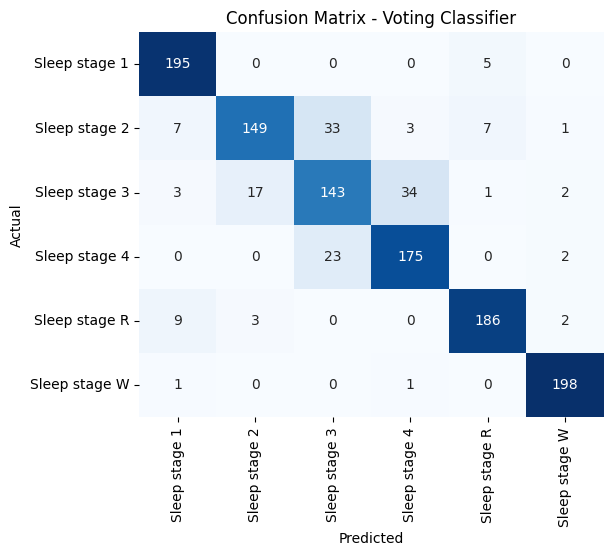


Classification Report (4 decimal places):

               precision    recall  f1-score   support

Sleep stage 1     0.9070    0.9750    0.9398       200
Sleep stage 2     0.8817    0.7450    0.8076       200
Sleep stage 3     0.7186    0.7150    0.7168       200
Sleep stage 4     0.8216    0.8750    0.8475       200
Sleep stage R     0.9347    0.9300    0.9323       200
Sleep stage W     0.9659    0.9900    0.9778       200

     accuracy                         0.8717      1200
    macro avg     0.8716    0.8717    0.8703      1200
 weighted avg     0.8716    0.8717    0.8703      1200


Results saved as voting_results.csv


In [ ]:
# === INSTALL PACKAGES ===
!pip install -q scikit-learn xgboost catboost pandas matplotlib

# === IMPORTS ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# === LOAD DATA ===
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

# === FEATURES & LABELS ===
X = df.iloc[:, :-1]   # all feature columns
y = df.iloc[:, -1]    # last column as label

# === TRAIN/TEST SPLIT ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# === BASE MODELS ===
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42)
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss"
)
cat = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_state=42
)

# === VOTING CLASSIFIER (SOFT VOTING) ===
voting_clf = VotingClassifier(
    estimators=[("gb", gb), ("xgb", xgb), ("cat", cat)],
    voting="soft",
    n_jobs=-1
)

# === TRAIN ===
voting_clf.fit(X_train, y_train)

# === PREDICT ===
y_pred = voting_clf.predict(X_test)

# === ACCURACY ===
acc = accuracy_score(y_test, y_pred)
print(f"Voting Classifier Accuracy: {acc*100:.2f}%")

# === CONFUSION MATRIX (RAW COUNTS, NO NORMALIZATION) ===
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix (Raw Counts):\n", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Voting Classifier")
plt.show()

# === CLASSIFICATION REPORT (4 DECIMAL PLACES) ===
print("\nClassification Report (4 decimal places):\n")
print(classification_report(y_test, y_pred, digits=4))

# === SAVE RESULTS TO CSV ===
report = classification_report(y_test, y_pred, output_dict=True, digits=4)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv("voting_results.csv", index=True)

print("\nResults saved as voting_results.csv")


WITH 45 Features

Saving balanced_dataset_1000_each_45_features.csv to balanced_dataset_1000_each_45_features.csv

✅ Loaded dataset: balanced_dataset_1000_each_45_features.csv
Shape: (6000, 46)
         F1        F2        F3        F4        F5        F6        F7  \
0  0.589533  0.008883  0.003874  0.693142  0.084044  0.744745  0.650514   
1  0.589918  0.041498  0.041232  0.693485  0.105907  0.707718  0.847431   
2  0.598189  0.037928  0.021031  0.707544  0.092083  0.725041  0.884066   
3  0.586869  0.054667  0.060465  0.687827  0.121315  0.694253  0.792411   
4  0.589219  0.032462  0.037261  0.693195  0.101463  0.708796  0.728375   

         F8        F9       F10  ...       F37       F38       F39       F40  \
0  0.095366  0.001450  0.002424  ...  0.008883  0.009198  0.000164  0.156508   
1  0.061662  0.018411  0.008801  ...  0.041498  0.053342  0.001469  0.093061   
2  0.018001  0.002491  0.002929  ...  0.037928  0.034550  0.001501  0.074255   
3  0.041746  0.035609  0.016245  ...  0.054667  0.079

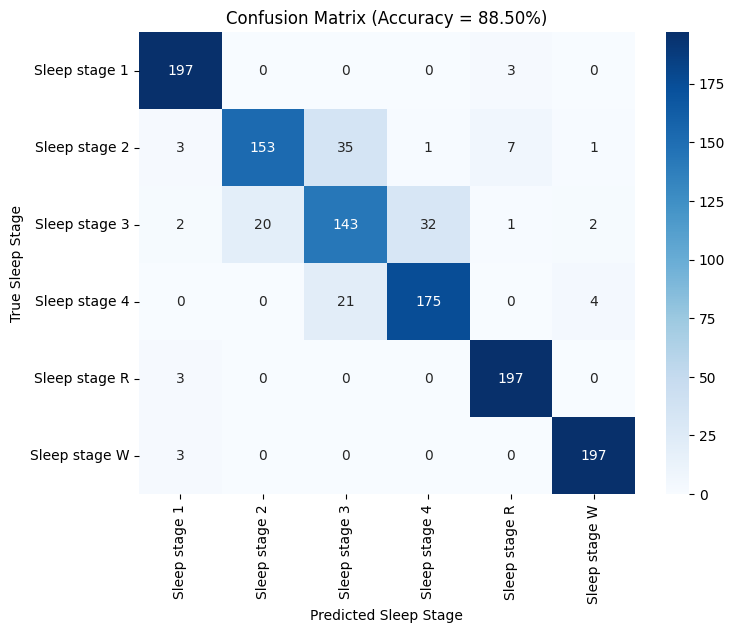

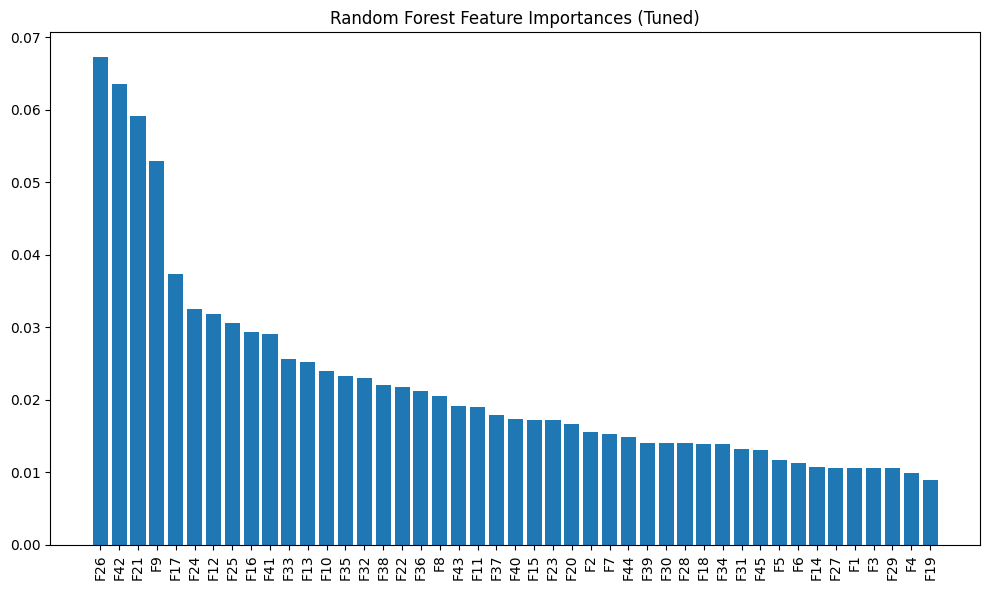

In [ ]:
# === INSTALL REQUIRED PACKAGES ===
!pip install -q scikit-learn pandas matplotlib seaborn

# === UPLOAD CSV FILE ===
from google.colab import files
uploaded = files.upload()

# === IMPORTS ===
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# === LOAD DATA ===
filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"\n✅ Loaded dataset: {filename}")
print(f"Shape: {df.shape}")
print(df.head())

# === SPLIT FEATURES AND LABEL ===
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Save original labels before encoding
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)
    class_names = le.classes_
else:
    class_names = np.unique(y).astype(str)

# === TRAIN/TEST SPLIT ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"\n📊 Train: {len(X_train)}, Test: {len(X_test)}")

# === RANDOM FOREST HYPERPARAMETER GRID ===
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# === RANDOMIZED SEARCH ===
base_model = RandomForestClassifier(random_state=42)
search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    scoring='accuracy'
)
search.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {search.best_params_}")

# === BEST MODEL PREDICTION ===
best_rf = search.best_estimator_
y_pred = best_rf.predict(X_test)

# === EVALUATION ===
acc = accuracy_score(y_test, y_pred)
print("\n🏆 Tuned Random Forest Evaluation:")
print("Test Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=class_names, digits=4))

# === CONFUSION MATRIX HEATMAP (RAW COUNTS) ===
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Sleep Stage")
plt.ylabel("True Sleep Stage")
plt.title(f"Confusion Matrix (Accuracy = {acc:.2%})")
plt.show()


# === FEATURE IMPORTANCE PLOT ===
importances = best_rf.feature_importances_
feat_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importances (Tuned)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feat_names[indices], rotation=90)
plt.tight_layout()
plt.show()


Saving balanced_dataset_1000_each_45_features.csv to balanced_dataset_1000_each_45_features (1).csv
Voting Classifier Accuracy: 86.67%

Confusion Matrix (Raw Counts):
 [[195   0   0   0   5   0]
 [  5 144  39   3   8   1]
 [  3  19 140  36   1   1]
 [  0   0  21 177   0   2]
 [  8   3   0   0 187   2]
 [  3   0   0   0   0 197]]


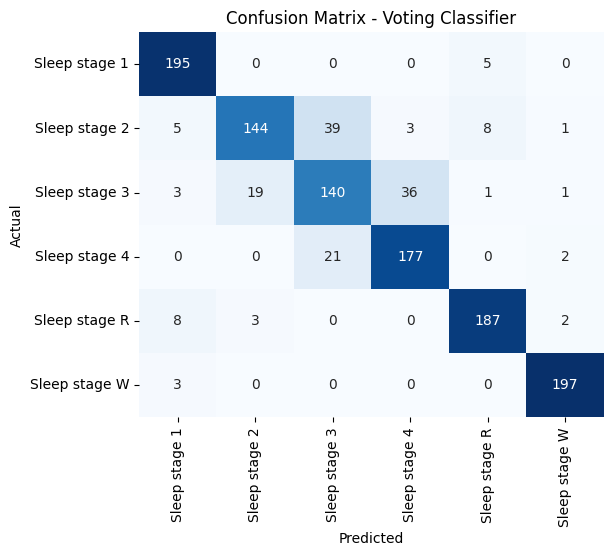


Classification Report (4 decimal places):

               precision    recall  f1-score   support

Sleep stage 1     0.9112    0.9750    0.9420       200
Sleep stage 2     0.8675    0.7200    0.7869       200
Sleep stage 3     0.7000    0.7000    0.7000       200
Sleep stage 4     0.8194    0.8850    0.8510       200
Sleep stage R     0.9303    0.9350    0.9327       200
Sleep stage W     0.9704    0.9850    0.9777       200

     accuracy                         0.8667      1200
    macro avg     0.8665    0.8667    0.8650      1200
 weighted avg     0.8665    0.8667    0.8650      1200


Results saved as voting_results.csv


In [ ]:
# === INSTALL PACKAGES ===
!pip install -q scikit-learn xgboost catboost pandas matplotlib

# === IMPORTS ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# === LOAD DATA ===
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

# === FEATURES & LABELS ===
X = df.iloc[:, :-1]   # all feature columns
y = df.iloc[:, -1]    # last column as label

# === TRAIN/TEST SPLIT ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# === BASE MODELS ===
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42)
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss"
)
cat = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_state=42
)

# === VOTING CLASSIFIER (SOFT VOTING) ===
voting_clf = VotingClassifier(
    estimators=[("gb", gb), ("xgb", xgb), ("cat", cat)],
    voting="soft",
    n_jobs=-1
)

# === TRAIN ===
voting_clf.fit(X_train, y_train)

# === PREDICT ===
y_pred = voting_clf.predict(X_test)

# === ACCURACY ===
acc = accuracy_score(y_test, y_pred)
print(f"Voting Classifier Accuracy: {acc*100:.2f}%")

# === CONFUSION MATRIX (RAW COUNTS, NO NORMALIZATION) ===
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix (Raw Counts):\n", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Voting Classifier")
plt.show()

# === CLASSIFICATION REPORT (4 DECIMAL PLACES) ===
print("\nClassification Report (4 decimal places):\n")
print(classification_report(y_test, y_pred, digits=4))

# === SAVE RESULTS TO CSV ===
report = classification_report(y_test, y_pred, output_dict=True, digits=4)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv("voting_results.csv", index=True)

print("\nResults saved as voting_results.csv")


Saving balanced_dataset_1000_each_45_features.csv to balanced_dataset_1000_each_45_features (2).csv


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [18:20:08] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Test Accuracy: 88.33 %

Classification Report (4 decimal places):

               precision    recall  f1-score   support

Sleep stage 1     0.9381    0.9850    0.9610       200
Sleep stage 2     0.8728    0.7550    0.8097       200
Sleep stage 3     0.7136    0.7100    0.7118       200
Sleep stage 4     0.8349    0.8850    0.8592       200
Sleep stage R     0.9557    0.9700    0.9628       200
Sleep stage W     0.9803    0.9950    0.9876       200

     accuracy                         0.8833      1200
    macro avg     0.8826    0.8833    0.8820      1200
 weighted avg     0.8826    0.8833    0.8820      1200



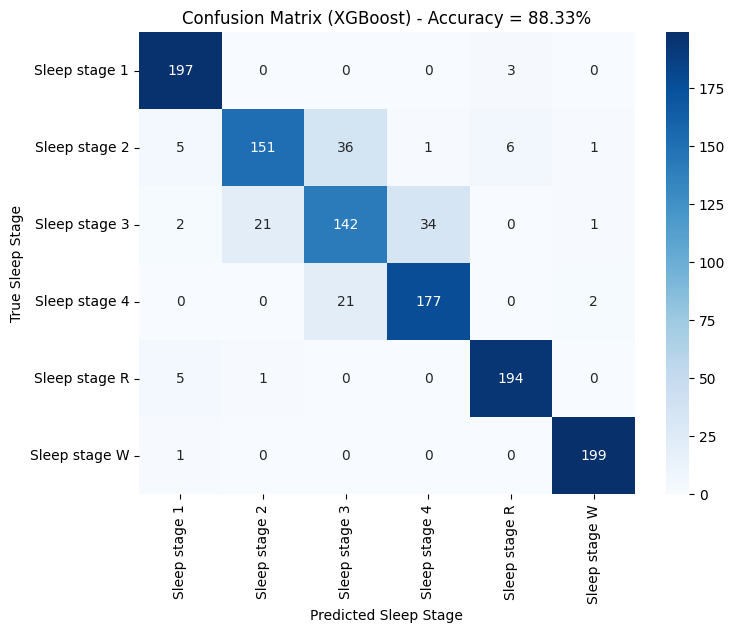

In [ ]:
# === INSTALL PACKAGES ===
!pip install -q scikit-learn pandas matplotlib xgboost

# === UPLOAD DATA ===
from google.colab import files
uploaded = files.upload()

# === IMPORTS ===
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# === READ DATA ===
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Separate features and label
X = df.drop(columns=['label'])
y = df['label']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# === TRAIN TEST SPLIT ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# === MODEL (XGBoost) ===
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# === EVALUATION ===
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", round(acc*100, 2), "%\n")

# Performance matrix (4 decimal places)
print("Classification Report (4 decimal places):\n")
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))

# Confusion Matrix (Raw Counts with Sleep Stage Labels)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted Sleep Stage")
plt.ylabel("True Sleep Stage")
plt.title(f"Confusion Matrix (XGBoost) - Accuracy = {round(acc*100,2)}%")
plt.show()


Saving balanced_dataset_1000_each_45_features.csv to balanced_dataset_1000_each_45_features (3).csv

✅ Loaded dataset: balanced_dataset_1000_each_45_features (3).csv
Shape: (6000, 46)
         F1        F2        F3        F4        F5        F6        F7  \
0  0.589533  0.008883  0.003874  0.693142  0.084044  0.744745  0.650514   
1  0.589918  0.041498  0.041232  0.693485  0.105907  0.707718  0.847431   
2  0.598189  0.037928  0.021031  0.707544  0.092083  0.725041  0.884066   
3  0.586869  0.054667  0.060465  0.687827  0.121315  0.694253  0.792411   
4  0.589219  0.032462  0.037261  0.693195  0.101463  0.708796  0.728375   

         F8        F9       F10  ...       F37       F38       F39       F40  \
0  0.095366  0.001450  0.002424  ...  0.008883  0.009198  0.000164  0.156508   
1  0.061662  0.018411  0.008801  ...  0.041498  0.053342  0.001469  0.093061   
2  0.018001  0.002491  0.002929  ...  0.037928  0.034550  0.001501  0.074255   
3  0.041746  0.035609  0.016245  ...  0.05466

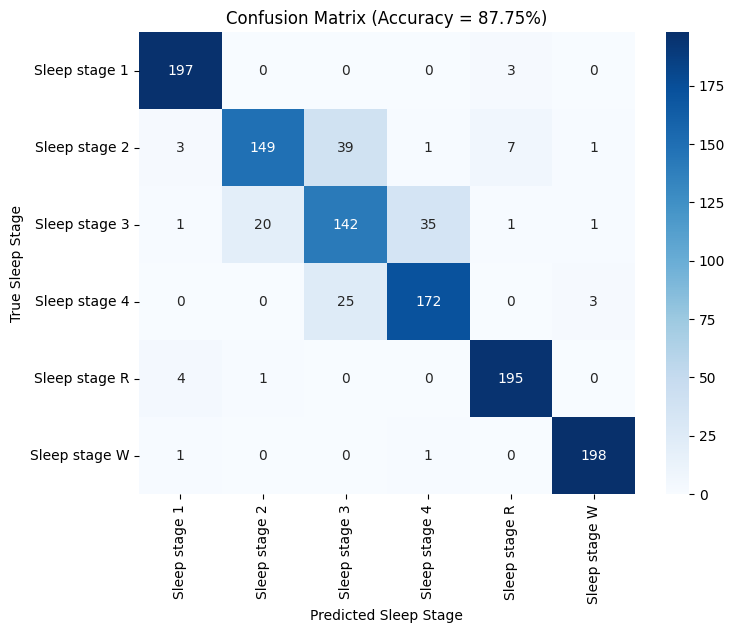


📊 Performance Matrix:
               precision  recall  f1-score    support
Sleep stage 1     0.9563  0.9850    0.9704   200.0000
Sleep stage 2     0.8765  0.7450    0.8054   200.0000
Sleep stage 3     0.6893  0.7100    0.6995   200.0000
Sleep stage 4     0.8230  0.8600    0.8411   200.0000
Sleep stage R     0.9466  0.9750    0.9606   200.0000
Sleep stage W     0.9754  0.9900    0.9826   200.0000
accuracy          0.8775  0.8775    0.8775     0.8775
macro avg         0.8778  0.8775    0.8766  1200.0000
weighted avg      0.8778  0.8775    0.8766  1200.0000


In [ ]:
# === INSTALL PACKAGES ===
!pip install -q scikit-learn xgboost catboost pandas matplotlib seaborn

# === UPLOAD CSV ===
from google.colab import files
uploaded = files.upload()

# === IMPORTS ===
import io
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder

# === LOAD DATA ===
filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"\n✅ Loaded dataset: {filename}")
print(f"Shape: {df.shape}")
print(df.head())

# === FEATURES & LABEL SPLIT ===
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Save label names
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)
    class_names = le.classes_
else:
    class_names = np.unique(y).astype(str)

# === TRAIN-TEST SPLIT ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"\n📊 Train: {len(X_train)}, Test: {len(X_test)}")

# === BASE MODELS ===
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
xgb = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5,
                    use_label_encoder=False, eval_metric='mlogloss', random_state=42)
cat = CatBoostClassifier(verbose=0, iterations=200, learning_rate=0.05, depth=5, random_state=42)

# === STACKING CLASSIFIER ===
stack_model = StackingClassifier(
    estimators=[
        ('gb', gb),
        ('xgb', xgb),
        ('cat', cat)
    ],
    final_estimator=LogisticRegression(max_iter=500),
    cv=5,
    n_jobs=-1,
    passthrough=True
)

# === TRAIN ===
stack_model.fit(X_train, y_train)
y_pred = stack_model.predict(X_test)

# === EVALUATION ===
acc = accuracy_score(y_test, y_pred)
print("\n🏆 Stacking Classifier Evaluation:")
print(f"Test Accuracy: {acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=class_names, digits=4))

# === CONFUSION MATRIX HEATMAP (RAW COUNTS) ===
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Sleep Stage")
plt.ylabel("True Sleep Stage")
plt.title(f"Confusion Matrix (Accuracy = {acc:.2%})")
plt.show()

# === PERFORMANCE MATRIX (DataFrame) ===
report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report).transpose()

print("\n📊 Performance Matrix:")
print(df_report.round(4))


Saving balanced_dataset_1000_each_45_features.csv to balanced_dataset_1000_each_45_features (4).csv

✅ Loaded dataset: balanced_dataset_1000_each_45_features (4).csv
Shape: (6000, 46)
         F1        F2        F3        F4        F5        F6        F7  \
0  0.589533  0.008883  0.003874  0.693142  0.084044  0.744745  0.650514   
1  0.589918  0.041498  0.041232  0.693485  0.105907  0.707718  0.847431   
2  0.598189  0.037928  0.021031  0.707544  0.092083  0.725041  0.884066   
3  0.586869  0.054667  0.060465  0.687827  0.121315  0.694253  0.792411   
4  0.589219  0.032462  0.037261  0.693195  0.101463  0.708796  0.728375   

         F8        F9       F10  ...       F37       F38       F39       F40  \
0  0.095366  0.001450  0.002424  ...  0.008883  0.009198  0.000164  0.156508   
1  0.061662  0.018411  0.008801  ...  0.041498  0.053342  0.001469  0.093061   
2  0.018001  0.002491  0.002929  ...  0.037928  0.034550  0.001501  0.074255   
3  0.041746  0.035609  0.016245  ...  0.05466

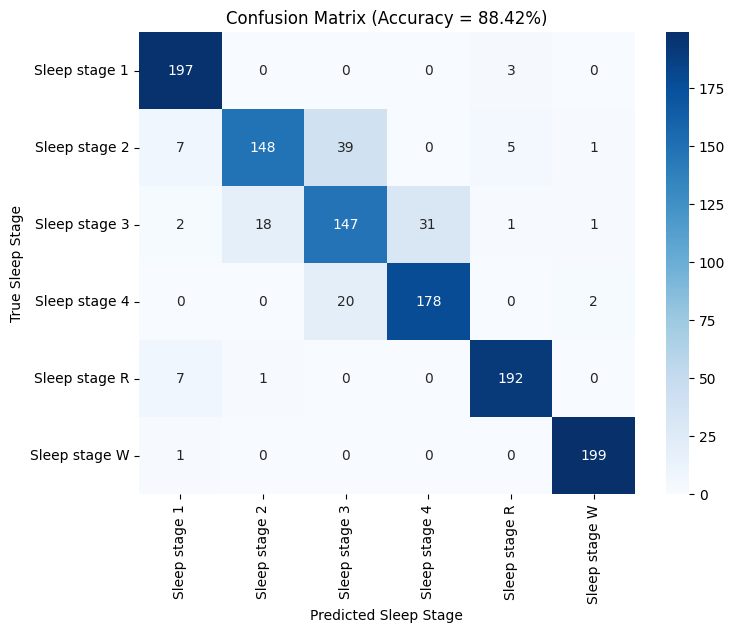

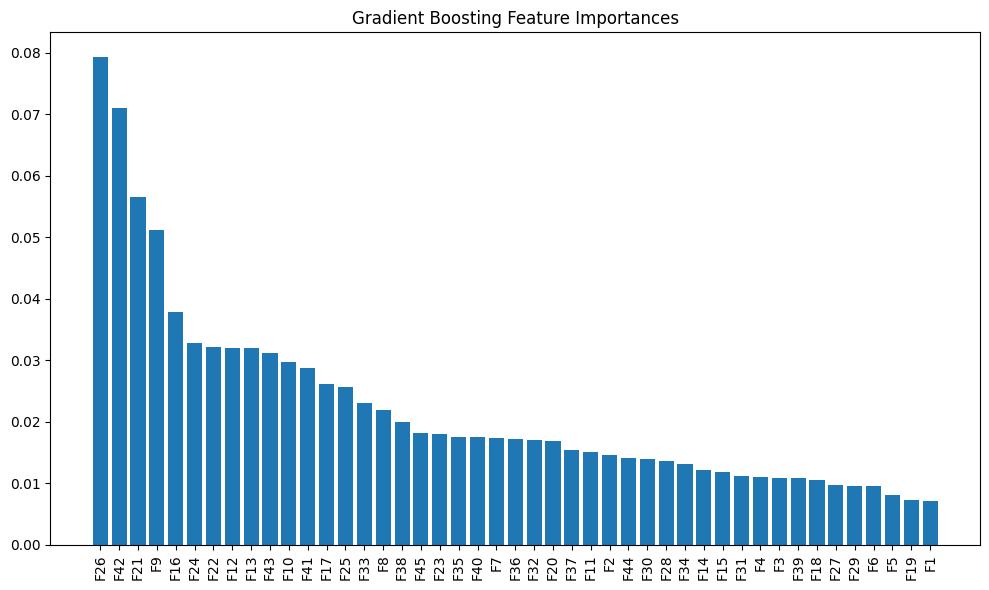

In [ ]:
# === INSTALL REQUIRED PACKAGES ===
!pip install -q scikit-learn pandas matplotlib seaborn

# === UPLOAD CSV FILE ===
from google.colab import files
uploaded = files.upload()

# === IMPORTS ===
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# === LOAD DATA ===
filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"\n✅ Loaded dataset: {filename}")
print(f"Shape: {df.shape}")
print(df.head())

# === SPLIT FEATURES / LABEL ===
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Save label names before encoding
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)
    class_names = le.classes_
else:
    class_names = np.unique(y).astype(str)

# === TRAIN/TEST SPLIT ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"\n📊 Train: {len(X_train)}, Test: {len(X_test)}")

# === GRADIENT BOOSTING HYPERPARAMETER GRID ===
param_dist = {
    'n_estimators': [150, 200, 300],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'subsample': [0.8, 1.0],
    'max_features': ['sqrt', 'log2']
}

# === RANDOMIZED SEARCH ===
base_model = GradientBoostingClassifier(random_state=42)
search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    scoring='accuracy'
)
search.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {search.best_params_}")

# === BEST MODEL PREDICTION ===
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

# === EVALUATION ===
acc = accuracy_score(y_test, y_pred)
print("\n🏆 Tuned Gradient Boosting Evaluation:")
print(f"Test Accuracy: {acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=class_names, digits=4))

# === CONFUSION MATRIX HEATMAP (RAW COUNTS) ===
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Sleep Stage")
plt.ylabel("True Sleep Stage")
plt.title(f"Confusion Matrix (Accuracy = {acc:.2%})")
plt.show()

# === FEATURE IMPORTANCE PLOT ===
importances = best_model.feature_importances_
feat_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Gradient Boosting Feature Importances")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feat_names[indices], rotation=90)
plt.tight_layout()
plt.show()


Saving reduced_dataset.csv to reduced_dataset.csv

✅ Loaded dataset: reduced_dataset.csv
Shape: (6000, 36)
         F9       F42       F21       F26       F16       F12       F24  \
0  0.001450  0.246886  0.349081  0.241975  0.022803  0.002483  0.002503   
1  0.018411  0.150352  0.415117  0.148971  0.027328  0.002500  0.002520   
2  0.002491  0.363919  0.138198  0.358848  0.031706  0.000914  0.000921   
3  0.035609  0.105593  0.413284  0.109465  0.023847  0.001085  0.001093   
4  0.010597  0.522701  0.444077  0.498765  0.084273  0.003159  0.003185   

        F17       F41        F7  ...        F5        F1       F32       F40  \
0  0.010650  0.033941  0.650514  ...  0.084044  0.589533  0.027243  0.156508   
1  0.019212  0.053624  0.847431  ...  0.105907  0.589918  0.048459  0.093061   
2  0.041206  0.130677  0.884066  ...  0.092083  0.598189  0.024242  0.074255   
3  0.016254  0.080090  0.792411  ...  0.121315  0.586869  0.031713  0.051852   
4  0.014569  0.058142  0.728375  ...  0.10

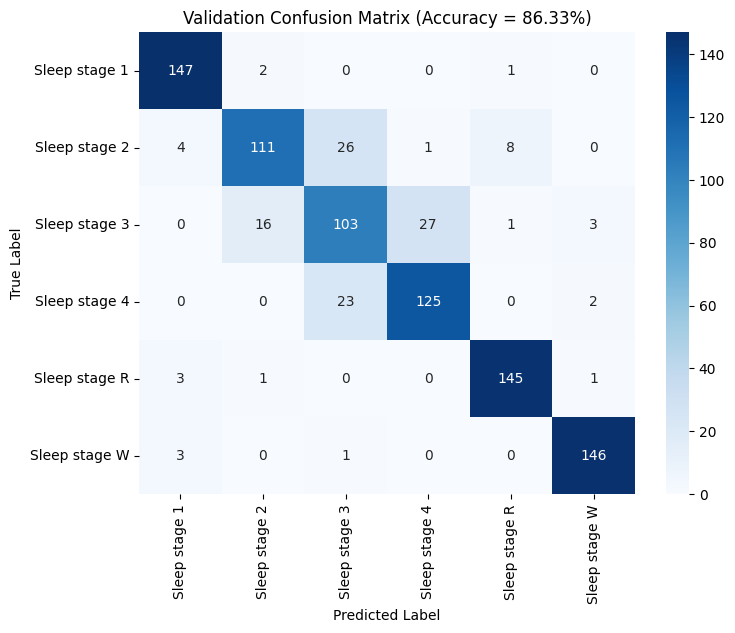

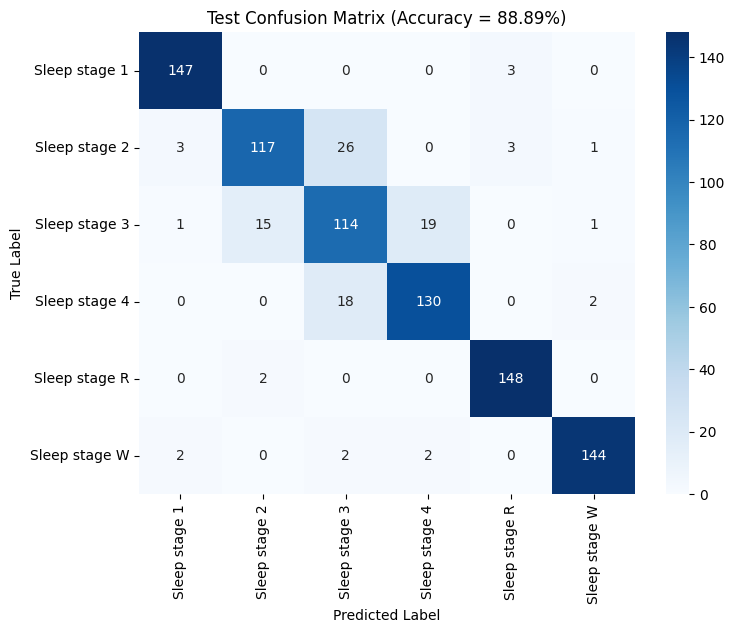

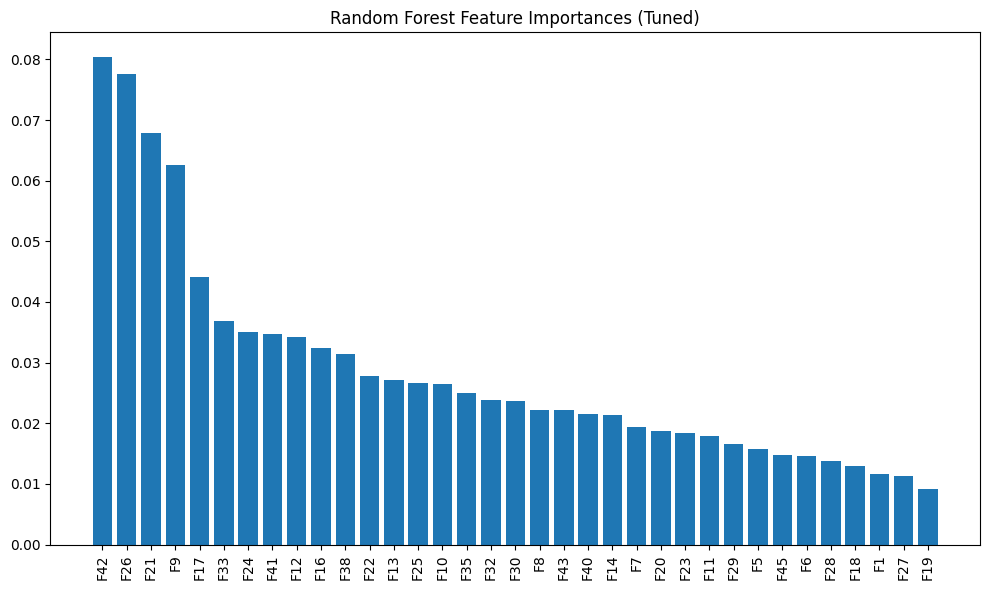

In [ ]:
# === INSTALL REQUIRED PACKAGES ===
!pip install -q scikit-learn pandas matplotlib seaborn

# === UPLOAD CSV FILE ===
from google.colab import files
uploaded = files.upload()

# === IMPORTS ===
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# === LOAD DATA ===
filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"\n✅ Loaded dataset: {filename}")
print(f"Shape: {df.shape}")
print(df.head())

# === SPLIT FEATURES AND LABEL ===
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Encode labels if categorical
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)
    class_names = le.classes_
else:
    class_names = np.unique(y).astype(str)

# === TRAIN / VALID / TEST SPLIT (70:15:15) ===
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"\n📊 Train: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")

# === RANDOM FOREST HYPERPARAMETER GRID ===
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# === RANDOMIZED SEARCH ===
base_model = RandomForestClassifier(random_state=42)
search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    scoring='accuracy'
)
search.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {search.best_params_}")

# === BEST MODEL ===
best_rf = search.best_estimator_

# Predictions
y_val_pred = best_rf.predict(X_val)
y_test_pred = best_rf.predict(X_test)

# === VALIDATION EVALUATION ===
val_acc = accuracy_score(y_val, y_val_pred)
print("\n📈 Validation Set Evaluation:")
print("Validation Accuracy:", val_acc)
print("\nClassification Report:\n", classification_report(y_val, y_val_pred, target_names=class_names, digits=4))

# === TEST EVALUATION ===
test_acc = accuracy_score(y_test, y_test_pred)
print("\n🏆 Test Set Evaluation:")
print("Test Accuracy:", test_acc)
print("\nClassification Report:\n", classification_report(y_test, y_test_pred, target_names=class_names, digits=4))

# === CONFUSION MATRIX HEATMAPS ===
def plot_conf_matrix(y_true, y_pred, acc, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"{title} (Accuracy = {acc:.2%})")
    plt.show()

plot_conf_matrix(y_val, y_val_pred, val_acc, "Validation Confusion Matrix")
plot_conf_matrix(y_test, y_test_pred, test_acc, "Test Confusion Matrix")

# === FEATURE IMPORTANCE PLOT ===
importances = best_rf.feature_importances_
feat_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importances (Tuned)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feat_names[indices], rotation=90)
plt.tight_layout()
plt.show()


Saving balanced_dataset_1000_each_45_features.csv to balanced_dataset_1000_each_45_features.csv

✅ Loaded dataset: balanced_dataset_1000_each_45_features.csv
Shape: (6000, 46)
         F1        F2        F3        F4        F5        F6        F7  \
0  0.589533  0.008883  0.003874  0.693142  0.084044  0.744745  0.650514   
1  0.589918  0.041498  0.041232  0.693485  0.105907  0.707718  0.847431   
2  0.598189  0.037928  0.021031  0.707544  0.092083  0.725041  0.884066   
3  0.586869  0.054667  0.060465  0.687827  0.121315  0.694253  0.792411   
4  0.589219  0.032462  0.037261  0.693195  0.101463  0.708796  0.728375   

         F8        F9       F10  ...       F37       F38       F39       F40  \
0  0.095366  0.001450  0.002424  ...  0.008883  0.009198  0.000164  0.156508   
1  0.061662  0.018411  0.008801  ...  0.041498  0.053342  0.001469  0.093061   
2  0.018001  0.002491  0.002929  ...  0.037928  0.034550  0.001501  0.074255   
3  0.041746  0.035609  0.016245  ...  0.054667  0.079

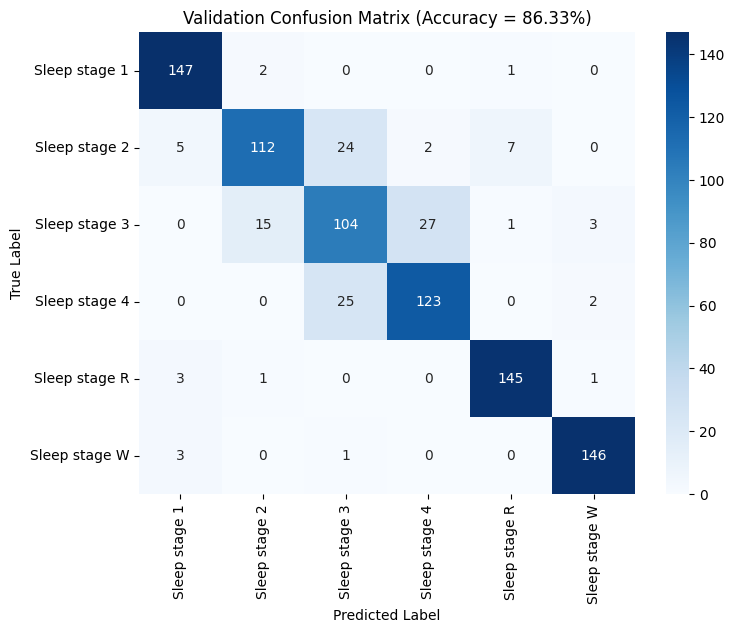

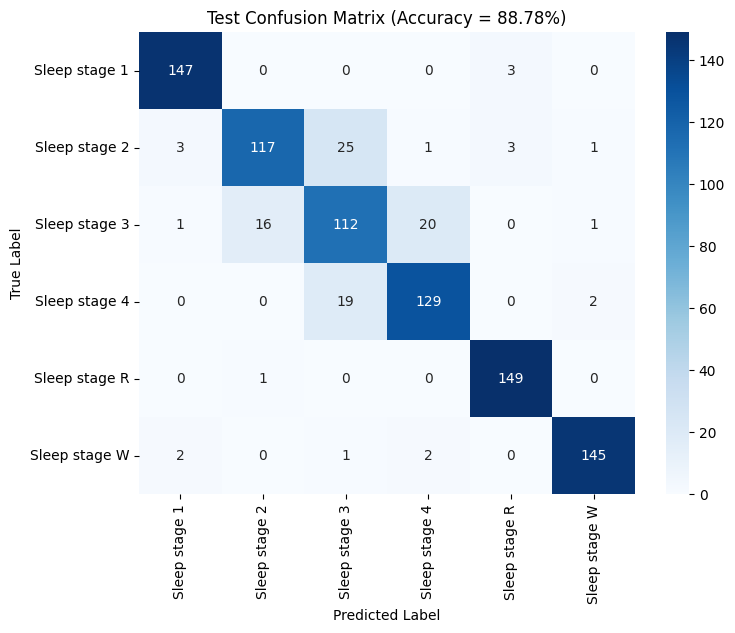

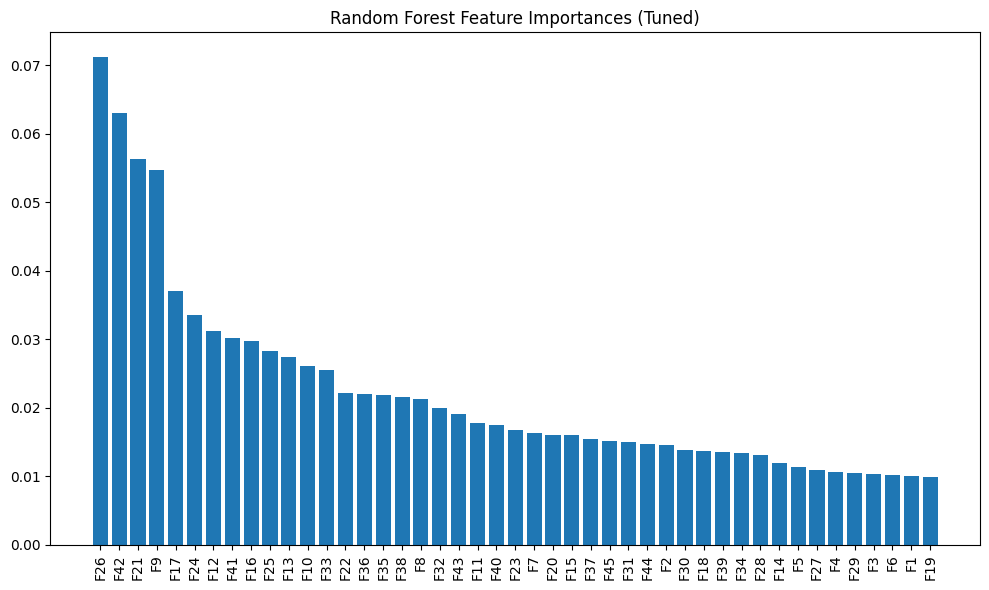

In [ ]:
# === INSTALL REQUIRED PACKAGES ===
!pip install -q scikit-learn pandas matplotlib seaborn

# === UPLOAD CSV FILE ===
from google.colab import files
uploaded = files.upload()

# === IMPORTS ===
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# === LOAD DATA ===
filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"\n✅ Loaded dataset: {filename}")
print(f"Shape: {df.shape}")
print(df.head())

# === SPLIT FEATURES AND LABEL ===
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Encode labels if categorical
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)
    class_names = le.classes_
else:
    class_names = np.unique(y).astype(str)

# === TRAIN / VALID / TEST SPLIT (70:15:15) ===
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"\n📊 Train: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")

# === RANDOM FOREST HYPERPARAMETER GRID ===
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# === RANDOMIZED SEARCH ===
base_model = RandomForestClassifier(random_state=42)
search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    scoring='accuracy'
)
search.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {search.best_params_}")

# === BEST MODEL ===
best_rf = search.best_estimator_

# Predictions
y_val_pred = best_rf.predict(X_val)
y_test_pred = best_rf.predict(X_test)

# === VALIDATION EVALUATION ===
val_acc = accuracy_score(y_val, y_val_pred)
print("\n📈 Validation Set Evaluation:")
print("Validation Accuracy:", val_acc)
print("\nClassification Report:\n", classification_report(y_val, y_val_pred, target_names=class_names, digits=4))

# === TEST EVALUATION ===
test_acc = accuracy_score(y_test, y_test_pred)
print("\n🏆 Test Set Evaluation:")
print("Test Accuracy:", test_acc)
print("\nClassification Report:\n", classification_report(y_test, y_test_pred, target_names=class_names, digits=4))

# === CONFUSION MATRIX HEATMAPS ===
def plot_conf_matrix(y_true, y_pred, acc, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"{title} (Accuracy = {acc:.2%})")
    plt.show()

plot_conf_matrix(y_val, y_val_pred, val_acc, "Validation Confusion Matrix")
plot_conf_matrix(y_test, y_test_pred, test_acc, "Test Confusion Matrix")

# === FEATURE IMPORTANCE PLOT ===
importances = best_rf.feature_importances_
feat_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importances (Tuned)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feat_names[indices], rotation=90)
plt.tight_layout()
plt.show()
